# Phase 1 — EDA + Clustering Tendency

DS-10 Credit Card Fraud. This notebook produces the figures embedded in `reports/phase1_report.pdf`
and computes Hopkins H + VAT on the engineered feature matrix.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from clustering_analysis.config import load_params
from clustering_analysis.io_utils import raw_path, interim_path, processed_path
from clustering_analysis.clean import clean_frame, write_decision_log
from clustering_analysis.features import engineer_features
from clustering_analysis.scaling import build_scaler, fit_and_describe
from clustering_analysis.reduce import fit_pca_for_variance, pca_explained_variance_curve, umap_embed
from clustering_analysis.tendency import hopkins_statistic, vat_ordering
from clustering_analysis.schemas import ProcessedSchema

# Resolve params.yaml from repo root (nbconvert runs kernel in notebooks/ dir).
_NB_CWD = Path.cwd()
_PARAMS_PATH = _NB_CWD / "params.yaml" if (_NB_CWD / "params.yaml").exists() else _NB_CWD.parent / "params.yaml"
REPO_ROOT = _PARAMS_PATH.parent
PARAMS = load_params(_PARAMS_PATH)
FIG = REPO_ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["figure.dpi"] = 120

## 1. Load raw, clean, feature-engineer

In [2]:
df_raw = pd.read_parquet(raw_path("creditcard.parquet"))
df_clean, stats = clean_frame(df_raw, drop_duplicates=PARAMS.clean.drop_duplicates)
write_decision_log(stats, REPO_ROOT / "reports" / "decision_log.md")
stats

{'input_rows': 284807,
 'duplicates_dropped': 1081,
 'output_rows': 283726,
 'n_fraud': 473,
 'n_legitimate': 283253}

In [3]:
df_feat = engineer_features(df_clean.drop(columns=["Class"]), period_seconds=PARAMS.features.time_period_seconds)
ProcessedSchema.validate(df_feat)  # stage-boundary contract: fail fast if shape/types drift
labels = df_clean["Class"].values
df_feat.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,log_amount,time_sin,time_cos
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0.000000,1.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0.000000,1.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0.000073,1.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0.000073,1.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0.000145,1.0


## 2. Scaling comparison (Strategy A / B / C)

In [4]:
summary = fit_and_describe(df_feat, v_features=PARAMS.scaling.v_features, robust_features=PARAMS.scaling.robust_features)
pd.DataFrame(summary).T

,log_amount_iqr_after,v1_mean_after,v1_std_after
standard,1.494292,-1.282216e-17,1.000002
robust,1.000000,-6.481533e-03,0.872764
hybrid,1.000000,-1.282216e-17,1.000002


Scaling-strategy comparison figure: V1 × V14 scatter under each strategy.

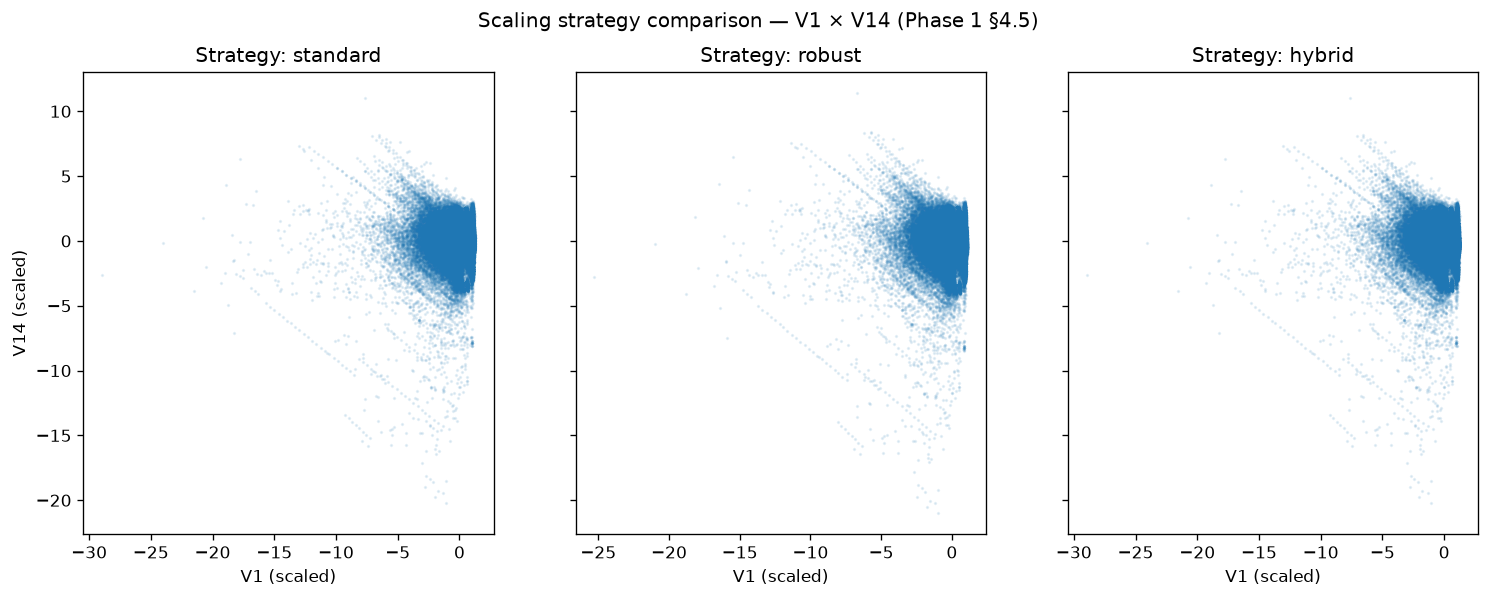

In [5]:
strategies = ["standard", "robust", "hybrid"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, strategy in zip(axes, strategies):
    sc = build_scaler(strategy, v_features=PARAMS.scaling.v_features, robust_features=PARAMS.scaling.robust_features)
    arr = sc.fit_transform(df_feat)
    df_arr = pd.DataFrame(arr, columns=PARAMS.scaling.v_features + PARAMS.scaling.robust_features)
    ax.scatter(df_arr["V1"], df_arr["V14"], s=1, alpha=0.1)
    ax.set_title(f"Strategy: {strategy}")
    ax.set_xlabel("V1 (scaled)")
axes[0].set_ylabel("V14 (scaled)")
fig.suptitle("Scaling strategy comparison — V1 × V14 (Phase 1 §4.5)")
fig.savefig(FIG / "scaling_comparison.pdf")
plt.show()

In [6]:
scaler = build_scaler(PARAMS.scaling.strategy, v_features=PARAMS.scaling.v_features, robust_features=PARAMS.scaling.robust_features)
X_scaled = scaler.fit_transform(df_feat)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (283726, 31)


Save the fitted scaler for downstream phases and the dashboard.

In [7]:
import joblib
processed_path("scaler.joblib").parent.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, processed_path("scaler.joblib").as_posix())

['/Users/snapp/github-projects/clustering-analysis/data/processed/scaler.joblib']

## 3. PCA explained-variance curve

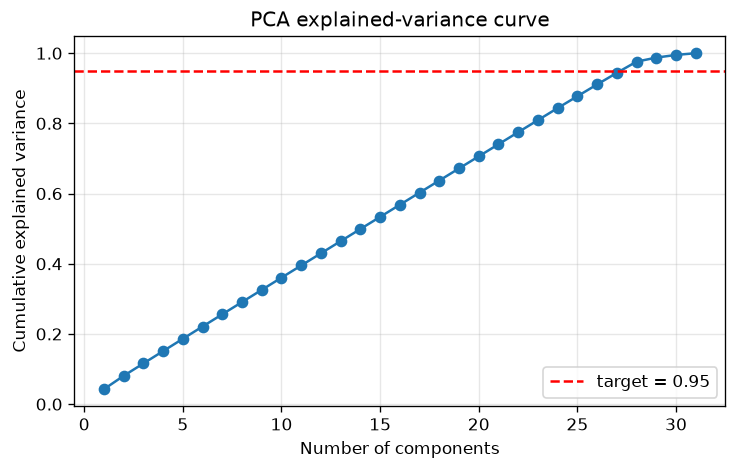

In [8]:
curve = pca_explained_variance_curve(X_scaled, max_components=X_scaled.shape[1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(curve) + 1), curve, marker="o")
ax.axhline(PARAMS.reduce.pca_variance, color="r", ls="--", label=f"target = {PARAMS.reduce.pca_variance}")
ax.set_xlabel("Number of components"); ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA explained-variance curve"); ax.legend(); ax.grid(alpha=0.3)
fig.savefig(FIG / "pca_explained_variance.pdf")
plt.show()

In [9]:
pca, n_pc = fit_pca_for_variance(X_scaled, target_variance=PARAMS.reduce.pca_variance)
X_pca = pca.transform(X_scaled)
print(f"Retained {n_pc} components for {PARAMS.reduce.pca_variance:.0%} variance")

Retained 28 components for 95% variance


## 4. UMAP embedding (2D for visualisation)

/Users/snapp/github-projects/clustering-analysis/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


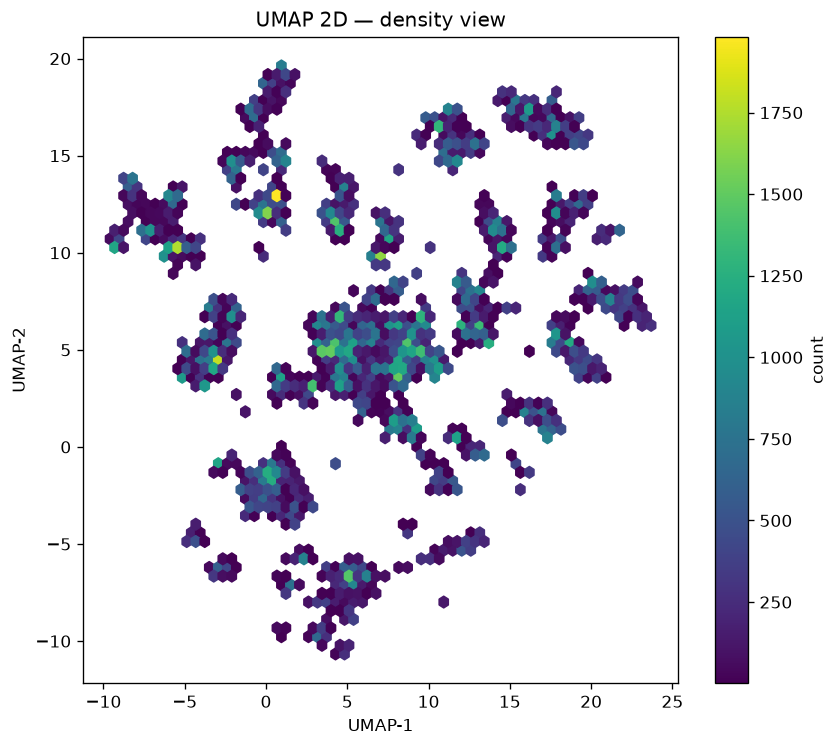

In [10]:
emb2 = umap_embed(X_scaled, n_neighbors=PARAMS.reduce.umap.n_neighbors, min_dist=PARAMS.reduce.umap.min_dist,
                  n_components=PARAMS.reduce.umap.n_components_viz, seed=PARAMS.seeds.reduce,
                  metric=PARAMS.reduce.umap.metric)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(emb2[:, 0], emb2[:, 1], gridsize=60, mincnt=1, cmap="viridis")
fig.colorbar(hb, label="count")
ax.set_title("UMAP 2D — density view"); ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
fig.savefig(FIG / "umap_density.pdf")
plt.show()

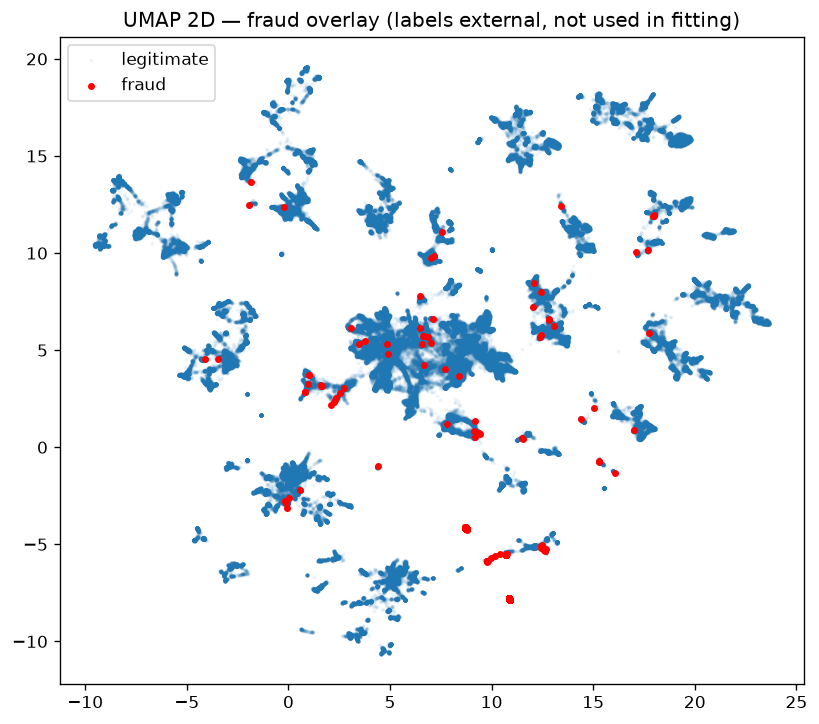

In [11]:
fraud_mask = labels == 1
fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(emb2[~fraud_mask, 0], emb2[~fraud_mask, 1], s=2, alpha=0.05, label="legitimate")
ax.scatter(emb2[fraud_mask, 0], emb2[fraud_mask, 1], s=10, color="red", label="fraud")
ax.set_title("UMAP 2D — fraud overlay (labels external, not used in fitting)"); ax.legend()
fig.savefig(FIG / "umap_fraud_overlay.pdf")
plt.show()

## 5. Hopkins statistic — 5 repeats

In [12]:
H_values = []
for i in range(PARAMS.tendency.hopkins.n_repeats):
    H = hopkins_statistic(X_scaled, sample_size=int(PARAMS.tendency.hopkins.sample_fraction * len(X_scaled)), seed=PARAMS.seeds.tendency + i)
    H_values.append(H)
H_mean, H_std = float(np.mean(H_values)), float(np.std(H_values))
print(f"Hopkins H = {H_mean:.3f} ± {H_std:.3f}  (threshold {PARAMS.tendency.hopkins.pass_threshold})")
assert H_mean >= PARAMS.tendency.hopkins.pass_threshold, "Hopkins below threshold — pivot per spec §2.7"

Hopkins H = 1.000 ± 0.000  (threshold 0.6)


## 6. VAT heatmap on stratified subsample

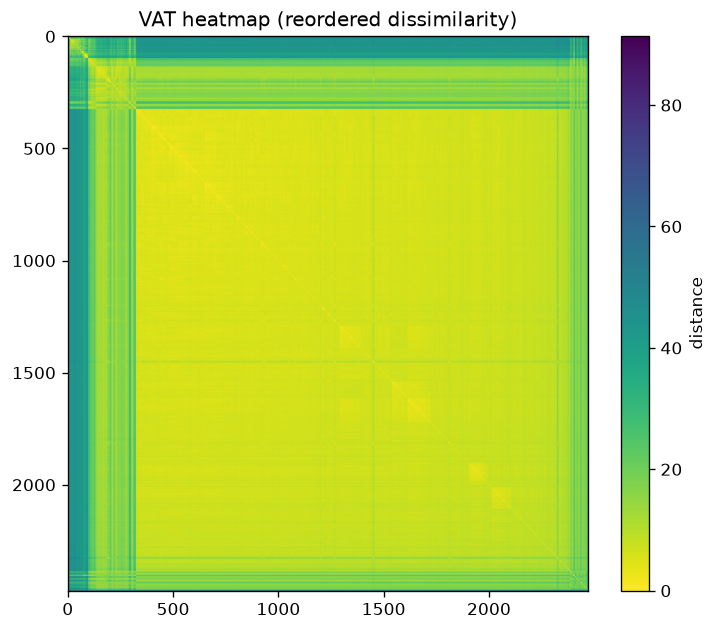

In [13]:
rng = np.random.default_rng(PARAMS.seeds.tendency)
legit_idx = rng.choice(np.where(~fraud_mask)[0], size=PARAMS.tendency.vat.n_legitimate, replace=False)
fraud_idx = np.where(fraud_mask)[0][:PARAMS.tendency.vat.n_fraud]
sub_idx = np.concatenate([legit_idx, fraud_idx])
X_sub = X_scaled[sub_idx]

order = vat_ordering(X_sub)
from scipy.spatial.distance import squareform, pdist
D = squareform(pdist(X_sub[order]))
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(D, cmap="viridis_r", aspect="auto")
fig.colorbar(im, label="distance")
ax.set_title("VAT heatmap (reordered dissimilarity)")
fig.savefig(FIG / "vat_heatmap.pdf")
plt.show()

## 7. Persist processed feature matrix for Phase 2

In [14]:
import numpy as np
np.save(processed_path("X_scaled.npy").as_posix(), X_scaled)
np.save(processed_path("X_pca.npy").as_posix(), X_pca)
np.save(processed_path("umap_2d.npy").as_posix(), emb2)
np.save(processed_path("labels.npy").as_posix(), labels)
print("Persisted: X_scaled, X_pca, umap_2d, labels")

Persisted: X_scaled, X_pca, umap_2d, labels
